In [1]:
#pip install tensorflow

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam,SGD,Adagrad

In [3]:
dt=pd.read_csv('wine.csv')

In [4]:
dt

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [5]:
dt.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')

In [6]:
dt['type']=dt['type'].map({"red":0,"white":1})

In [7]:
dt

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,1
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,1
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,1
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,1


In [8]:
x=dt.drop('type',axis=1)
y=dt[ 'type']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [10]:
x_train.shape

(5197, 12)

In [11]:
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [12]:

model = Sequential()
model.add(Dense(100, input_dim = 12, activation = 'relu'))
model.add(Dense(200, activation= 'relu'))
model.add(Dropout (0.5))
model.add(Dense(300, activation= 'relu')) 
model.add(Dense(100, activation= 'relu'))
model.add(Dropout(0.3))
model.add(Dense(50, activation='relu')) 
model.add(Dense(1, activation= 'sigmoid'))

callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=10)
model.compile(loss = 'binary_crossentropy',optimizer = SGD(learning_rate=0.05), metrics=['accuracy'])
model.summary()

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 100)                 │           1,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 200)                 │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 300)                 │          60,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,001 (457.04 KB)

 Trainable params: 117,001 (457.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
training_info = model.fit(x_train,y_train, batch_size=100, epochs=100,
                         validation_data=(x_test,y_test),
                         callbacks=callbacks)

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7416 - loss: 0.6295 - val_accuracy: 0.7715 - val_loss: 0.5311
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7537 - loss: 0.5490 - val_accuracy: 0.7715 - val_loss: 0.4987
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7499 - loss: 0.5201 - val_accuracy: 0.7715 - val_loss: 0.4088
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7552 - loss: 0.4211 - val_accuracy: 0.9569 - val_loss: 0.2484
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9182 - loss: 0.2570 - val_accuracy: 0.9769 - val_loss: 0.1292
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9683 - loss: 0.1436 - val_accuracy: 0.9792 - val_loss: 0.0852
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9776 - loss: 0.0901 - val_accuracy: 0.9762 - val_loss: 0.0825
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9749 - loss: 0.0851 - val_accuracy: 0.9854 - 

In [14]:
hist=training_info.history

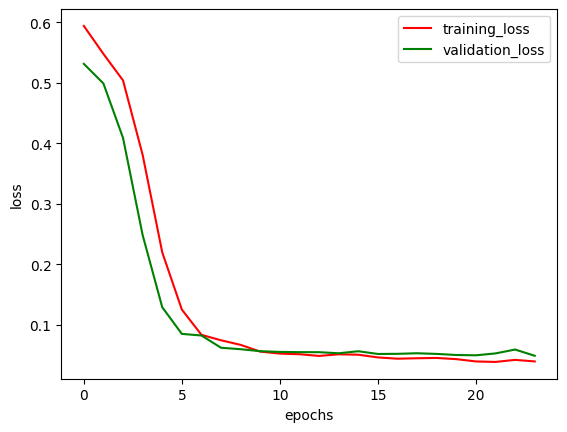

In [16]:
plt.plot(hist['loss'],label='training_loss',color='red')
plt.plot(hist['val_loss'],label='validation_loss',color='green')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

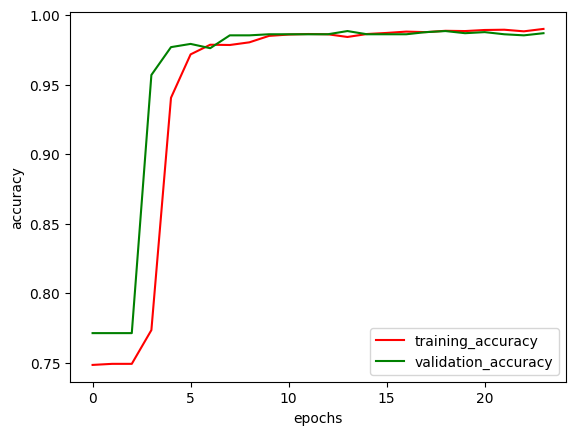

In [17]:
plt.plot(hist['accuracy'],label='training_accuracy',color='red')
plt.plot(hist['val_accuracy'],label='validation_accuracy',color='green')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

In [18]:
y_pred = model.predict(x_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [19]:
y_pred

array([[0.9991527 ],
       [0.9997782 ],
       [0.96575725],
       ...,
       [0.00228242],
       [0.0118845 ],
       [0.9988685 ]], dtype=float32)

In [20]:
y_pred = ((y_pred[:,0])>0.5).astype('int') #converting these probability values into ones and zeroes

In [21]:
y_pred

array([1, 1, 1, ..., 0, 0, 1])

In [26]:
# (batch_size, rows, columns, channels)
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1],x_train.shape[2], 1))
# X_ train = x_train.reshape((60000, 28,28, 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1],
x_test. shape [2] ,1))
# x_test = x_test.reshape((10000, 28,28,1))
x_train. shape

IndexError: tuple index out of range